In [304]:
# In this case the local root of the repo is our working directory
DIRECTORY = '../../'
font = 'arial'




# We declare this function here and not in the
# function-storing python file to modify it easily
# as it can change the printouts of the methods
def printout(V, Stats, model): 
    # printing Stats
    print("R2 = %.2f (+/- %.2f) Constraint = %.2f (+/- %.2f)" % \
          (Stats.train_objective[0], Stats.train_objective[1],
           Stats.train_loss[0], Stats.train_loss[1]))
    Vout = tf.convert_to_tensor(np.float32(model.Y))
    Loss_norm, dLoss = Loss_Vout(V, model.Pout, Vout)
    print('Loss Targets', np.mean(Loss_norm))
    Loss_norm, dLoss = Loss_SV(V, model.S)
    print('Loss SV', np.mean(Loss_norm))
    Vin = tf.convert_to_tensor(np.float32(model.X))
    Pin = tf.convert_to_tensor(np.float32(model.Pin))
    if Vin.shape[1] == model.S.shape[1]: # special case
        Vin  = tf.linalg.matmul(Vin, tf.transpose(Pin), b_is_sparse=True)
    Loss_norm, dLoss = Loss_Vin(V, model.Pin, Vin, model.mediumbound,model)
    print('Loss Vin bound', np.mean(Loss_norm))
    Loss_norm, dLoss = Loss_Vpos(V, model)
    print('Loss V positive', np.mean(Loss_norm))

In [306]:
import sys
sys.path.insert(0, DIRECTORY)

from Lab_Notebooks.AMN.utils import load_experiment_data


per_strain = True
replication = "replicates"
strain = "WT"
experiment = "mediabotJLF1"
well_column = "wells"
gr_column = "mv_mu_max"

df_WT, df_exp_data_WT, df_levels_WT = load_experiment_data(per_strain=per_strain,
                                replication=replication,
                                strain=strain,
                                experiment=experiment,
                                well_column=well_column,
                                gr_column=gr_column)

## QP solver

## One Sample

In [328]:
import shutil
import numpy as np
from Library.Build_Model_lite_grads import Neural_Model, TrainingSet, MM_QP

# Run Mechanistic model (no training) QP (quadratic program) or LP (linear program)
# using E. coli core simulation training sets and EB (or UB) bounds

# What you can change
seed = 10
np.random.seed(seed=seed)  
strain = "WT"
trainname = f'{strain}_UB_reduced_1_levels_20_max_20' # the training set file name
size = int(trainname.split('_')[-5]) # number of runs must be lower than the number of element in trainname
levels = int(trainname.split('_')[-3]) # Samples levels
max_val = int(trainname.split('_')[-1]) # Maximum value for levels
timestep =  int(1.0e4) # LP 1.0e4 QP 1.0e5
learn_rate = 1.0 # LP 0.3 QP 1.0
decay_rate = 0.9 # only in QP, UB 0.333 EB 0.9
# End of What you can change

# Create model and run GD for X and Y randomly drawn from trainingfile
trainingfile = DIRECTORY+'Dataset_model/'+trainname

# Copy the model without size
# remove the size part if present
new_train_name = "_".join(trainname.split('_')[:-1])
trainingfile = './Dataset_model/'+new_train_name
# copy the model and paste with new name
shutil.copyfile(DIRECTORY+'Dataset_model/'+trainname + ".npz", trainingfile + ".npz")
shutil.copyfile(DIRECTORY+'Dataset_model/'+trainname + ".xml", trainingfile + ".xml")

print(f"Training file used: {trainingfile}")

biomass_reaction_name = 'BIOMASS_Ec_iML1515_core_75p37M'
# Get the target index for biomass reaction
original_parameter = TrainingSet()
original_parameter.load(trainingfile)
target_index = [r.id for r in original_parameter.model.reactions].index(biomass_reaction_name)
size = original_parameter.Y.shape[0]

model = Neural_Model(trainingfile = trainingfile, 
              objective=[biomass_reaction_name],#['BIOMASS_Ecoli_core_w_GAM'], 
              model_type = 'MM_QP', 
              timestep = timestep, 
              learn_rate = learn_rate, 
              decay_rate = decay_rate)

# Select a random subset of the training set (of specified size)
ID = np.random.choice(model.X.shape[0], size, replace=False)
model.X, model.Y = model.X[ID,:], model.Y[ID,:]

# Prints a summary of the model before running
model.printout()

# Runs the appropriate method
if model.model_type is 'MM_QP':
    Ypred, Stats, grad_history = MM_QP(model, verbose=True)

# Printing results
printout(Ypred, Stats, model)

Training file used: ./Dataset_model/WT_UB_reduced_1_levels_20_max
Loading model from: c:\Users\rh2310\projects\amn_release\Lab_Notebooks\AMN\..\..\Dataset_model\WT_UB_reduced_1_levels_20_max_20.xml: True
Loading model from: c:\Users\rh2310\projects\amn_release\Lab_Notebooks\AMN\..\..\Dataset_model\WT_UB_reduced_1_levels_20_max_20.xml: True
training file: ./Dataset_model/WT_UB_reduced_1_levels_20_max
model type: MM_QP
model scaler: 0.0
model input dim: 46
model output dim: 1
model medium bound: UB
timestep: 10000
training set size (98, 46) (98, 1)
QP-Loss 1 0.499507 0.04185751 GradNorm: 13.96834659576416
QP-Loss 10 0.13345888 0.011077448 GradNorm: 6.716411590576172
QP-Loss 100 0.010514402 0.0007395734 GradNorm: 0.052374161779880524
QP-Loss 1000 0.003579601 0.00015858086 GradNorm: 0.004669759422540665
QP-Loss 2000 0.0023963172 6.1417806e-05 GradNorm: 0.002241755137220025
QP-Loss 3000 0.0020813397 3.7216934e-05 GradNorm: 0.0012190518900752068
QP-Loss 4000 0.0019694008 3.0030138e-05 GradNo

## Ten Samples

In [329]:
import shutil
import numpy as np
from Library.Build_Model_lite_grads import Neural_Model, TrainingSet, MM_QP

# Run Mechanistic model (no training) QP (quadratic program) or LP (linear program)
# using E. coli core simulation training sets and EB (or UB) bounds

# What you can change
seed = 10
np.random.seed(seed=seed)  
strain = "WT"
trainname = f'{strain}_UB_reduced_10_levels_20_max_20' # the training set file name
size = int(trainname.split('_')[-5]) # number of runs must be lower than the number of element in trainname
levels = int(trainname.split('_')[-3]) # Samples levels
max_val = int(trainname.split('_')[-1]) # Maximum value for levels
timestep =  int(1.0e4) # LP 1.0e4 QP 1.0e5
learn_rate = 1.0 # LP 0.3 QP 1.0
decay_rate = 0.9 # only in QP, UB 0.333 EB 0.9
# End of What you can change

# Create model and run GD for X and Y randomly drawn from trainingfile
trainingfile = DIRECTORY+'Dataset_model/'+trainname

# Copy the model without size
# remove the size part if present
new_train_name = "_".join(trainname.split('_')[:-1])
trainingfile = './Dataset_model/'+new_train_name
# copy the model and paste with new name
shutil.copyfile(DIRECTORY+'Dataset_model/'+trainname + ".npz", trainingfile + ".npz")
shutil.copyfile(DIRECTORY+'Dataset_model/'+trainname + ".xml", trainingfile + ".xml")

print(f"Training file used: {trainingfile}")

biomass_reaction_name = 'BIOMASS_Ec_iML1515_core_75p37M'
# Get the target index for biomass reaction
original_parameter = TrainingSet()
original_parameter.load(trainingfile)
target_index = [r.id for r in original_parameter.model.reactions].index(biomass_reaction_name)
size = original_parameter.Y.shape[0]

model = Neural_Model(trainingfile = trainingfile, 
              objective=[biomass_reaction_name],#['BIOMASS_Ecoli_core_w_GAM'], 
              model_type = 'MM_QP', 
              timestep = timestep, 
              learn_rate = learn_rate, 
              decay_rate = decay_rate)

# Select a random subset of the training set (of specified size)
ID = np.random.choice(model.X.shape[0], size, replace=False)
model.X, model.Y = model.X[ID,:], model.Y[ID,:]

# Prints a summary of the model before running
model.printout()

# Runs the appropriate method
if model.model_type is 'MM_QP':
    Ypred, Stats, grad_history = MM_QP(model, verbose=True)

# Printing results
printout(Ypred, Stats, model)

Training file used: ./Dataset_model/WT_UB_reduced_10_levels_20_max
Loading model from: c:\Users\rh2310\projects\amn_release\Lab_Notebooks\AMN\..\..\Dataset_model\WT_UB_reduced_10_levels_20_max_20.xml: True
Loading model from: c:\Users\rh2310\projects\amn_release\Lab_Notebooks\AMN\..\..\Dataset_model\WT_UB_reduced_10_levels_20_max_20.xml: True
training file: ./Dataset_model/WT_UB_reduced_10_levels_20_max
model type: MM_QP
model scaler: 0.0
model input dim: 46
model output dim: 1
model medium bound: UB
timestep: 10000
training set size (980, 46) (980, 1)
QP-Loss 1 0.50140244 0.047479365 GradNorm: 44.255802154541016
QP-Loss 10 0.1339593 0.012565359 GradNorm: 21.27955436706543
QP-Loss 100 0.010525226 0.0008370396 GradNorm: 0.16599635779857635
QP-Loss 1000 0.003530179 0.00017478595 GradNorm: 0.014729437418282032
QP-Loss 2000 0.0023664038 6.683627e-05 GradNorm: 0.006973959505558014
QP-Loss 3000 0.0020641948 4.0693038e-05 GradNorm: 0.0037643194664269686
QP-Loss 4000 0.0019575749 3.3069333e-05

## 120 Samples

In [330]:
import shutil
import numpy as np
from Library.Build_Model_lite_grads import Neural_Model, TrainingSet, MM_QP

# Run Mechanistic model (no training) QP (quadratic program) or LP (linear program)
# using E. coli core simulation training sets and EB (or UB) bounds

# What you can change
seed = 10
np.random.seed(seed=seed)  
strain = "WT"
trainname = f'{strain}_UB_reduced_120_levels_50_max_20' # the training set file name
size = int(trainname.split('_')[-5]) # number of runs must be lower than the number of element in trainname
levels = int(trainname.split('_')[-3]) # Samples levels
max_val = int(trainname.split('_')[-1]) # Maximum value for levels
timestep =  int(1.0e4) # LP 1.0e4 QP 1.0e5
learn_rate = 1.0 # LP 0.3 QP 1.0
decay_rate = 0.8 # only in QP, UB 0.333 EB 0.9
# End of What you can change

# Create model and run GD for X and Y randomly drawn from trainingfile
trainingfile = DIRECTORY+'Dataset_model/'+trainname

# Copy the model without size
# remove the size part if present
new_train_name = "_".join(trainname.split('_')[:-1])
trainingfile = './Dataset_model/'+new_train_name
# copy the model and paste with new name
shutil.copyfile(DIRECTORY+'Dataset_model/'+trainname + ".npz", trainingfile + ".npz")
shutil.copyfile(DIRECTORY+'Dataset_model/'+trainname + ".xml", trainingfile + ".xml")

print(f"Training file used: {trainingfile}")

biomass_reaction_name = 'BIOMASS_Ec_iML1515_core_75p37M'
# Get the target index for biomass reaction
original_parameter = TrainingSet()
original_parameter.load(trainingfile)
target_index = [r.id for r in original_parameter.model.reactions].index(biomass_reaction_name)
size = original_parameter.Y.shape[0]

model = Neural_Model(trainingfile = trainingfile, 
              objective=[biomass_reaction_name],#['BIOMASS_Ecoli_core_w_GAM'], 
              model_type = 'MM_QP', 
              timestep = timestep, 
              learn_rate = learn_rate, 
              decay_rate = decay_rate)

# Select a random subset of the training set (of specified size)
ID = np.random.choice(model.X.shape[0], size, replace=False)
model.X, model.Y = model.X[ID,:], model.Y[ID,:]

# Prints a summary of the model before running
model.printout()

# Runs the appropriate method
if model.model_type is 'MM_QP':
    Ypred, Stats, grad_history = MM_QP(model, verbose=True)

# Printing results
printout(Ypred, Stats, model)

Training file used: ./Dataset_model/WT_UB_reduced_120_levels_50_max
Loading model from: c:\Users\rh2310\projects\amn_release\Lab_Notebooks\AMN\..\..\Dataset_model\WT_UB_reduced_120_levels_50_max_20.xml: True
Loading model from: c:\Users\rh2310\projects\amn_release\Lab_Notebooks\AMN\..\..\Dataset_model\WT_UB_reduced_120_levels_50_max_20.xml: True
training file: ./Dataset_model/WT_UB_reduced_120_levels_50_max
model type: MM_QP
model scaler: 0.0
model input dim: 46
model output dim: 1
model medium bound: UB
timestep: 10000
training set size (11760, 46) (11760, 1)
QP-Loss 1 0.49834654 0.046298467 GradNorm: 152.8376007080078
QP-Loss 10 0.034275897 0.0030353602 GradNorm: 29.982683181762695
QP-Loss 100 0.011602129 0.0009217136 GradNorm: 0.18135930597782135
QP-Loss 1000 0.005404428 0.0003451123 GradNorm: 0.08569207787513733
QP-Loss 2000 0.0035128882 0.00017008022 GradNorm: 0.050909895449876785
QP-Loss 3000 0.0027353365 9.889459e-05 GradNorm: 0.03441756218671799
QP-Loss 4000 0.0023588473 6.5087

# Test on all data

In [331]:
import pandas as pd
from matplotlib import pyplot as plt
import copy

replication = "no_replicates"

gr_column= "mv_mu_max"
exp_data_path = f"H:/ROBOT_SCIENTIST/E_coli/Growth_rates/2025-10-31-27/processed/{replication}_STRAINS/{strain}/AMN_dataset/"
exp_data = pd.read_csv(exp_data_path + "df_flux.csv")


model2  = copy.deepcopy(model)

model2.Y = exp_data[gr_column].values.reshape(-1,1)
model2.X = exp_data.values[:,:-1]#model2.X[:model2.Y.shape[0], :]

if model2.model_type is 'MM_QP':
    Ypred, Stats, _ = MM_QP(model2, verbose=True)

QP-Loss 1 0.018902145 0.009873587 GradNorm: 3.795797824859619
QP-Loss 10 0.0016396687 0.0006494773 GradNorm: 0.7446349263191223
QP-Loss 100 0.00079597806 0.00019885728 GradNorm: 0.004517351742833853
QP-Loss 1000 0.0005626994 7.597944e-05 GradNorm: 0.002155626192688942
QP-Loss 2000 0.00048933126 3.875639e-05 GradNorm: 0.0013093537418171763
QP-Loss 3000 0.00045743553 2.3704539e-05 GradNorm: 0.0009191145654767752
QP-Loss 4000 0.0004405025 1.6633485e-05 GradNorm: 0.0006879134452901781
QP-Loss 5000 0.0004303753 1.3154081e-05 GradNorm: 0.0005469327443279326
QP-Loss 6000 0.00042356644 1.1369459e-05 GradNorm: 0.00046382052823901176
QP-Loss 7000 0.00041838654 1.0400905e-05 GradNorm: 0.00041660061106085777
QP-Loss 8000 0.00041404468 9.836153e-06 GradNorm: 0.0003900844312738627
QP-Loss 9000 0.00041015554 9.479028e-06 GradNorm: 0.00037481679464690387
QP-Loss 10000 0.00040653298 9.233852e-06 GradNorm: 0.00036546096089296043
AMN output shapes for PoutV, SV, PinV, Vpos, V, outputs (195, 1) (195, 1) (

In [332]:
model2.Y.shape, model2.X.shape, Ypred.shape, model2.Pout.shape

((195, 1), (195, 46), (195, 564), (1, 564))

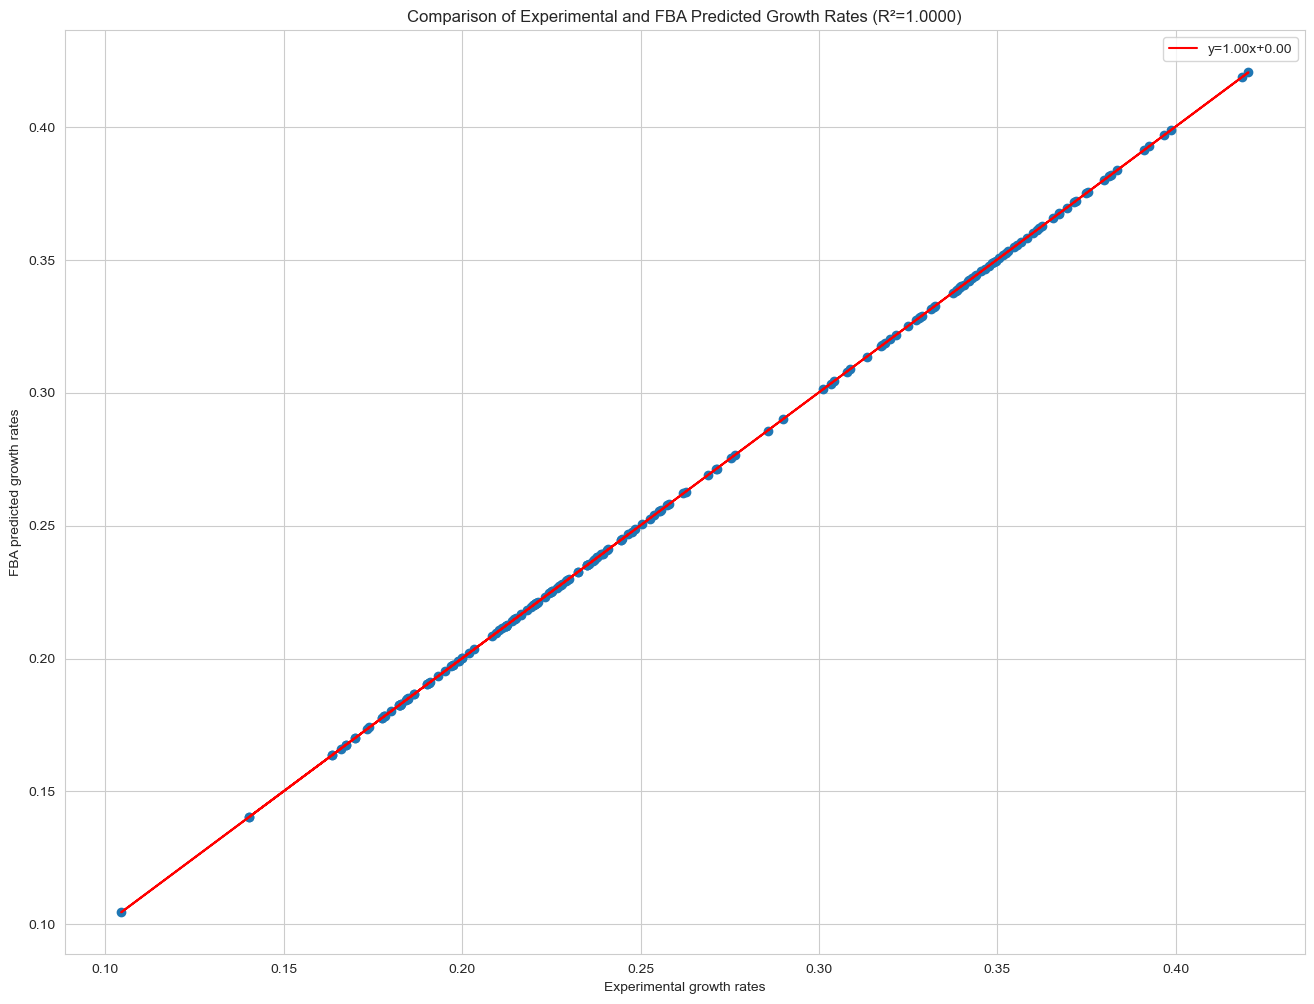

In [333]:
import pandas as pd
from matplotlib import pyplot as plt
replication = "no_replicates"

gr_column= "mv_mu_max"
targets = exp_data[gr_column].values.reshape(-1,1)

yhat = np.matmul(Ypred, model2.Pout.T)
plt.scatter(yhat, targets)
# regression line

y = np.array(targets).flatten()
x = np.array(yhat).flatten()
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', label=f'y={m:.2f}x+{b:.2f}')
# find R2
correlation_matrix = np.corrcoef(x, y)
correlation_xy = correlation_matrix[0,1]
r_squared = correlation_xy**2
plt.xlabel("Experimental growth rates")
plt.ylabel("FBA predicted growth rates")
plt.title(f"Comparison of Experimental and FBA Predicted Growth Rates (R²={r_squared:.4f})")
plt.legend()
plt.show()